Restauracion parcial o significativamente con una iamgen Moire

Primero se parte de una imagen afectada por el patrón de moiré.
Luego se aplica un filtro gaussiano para suavizar la imagen y reducir las variaciones bruscas de intensidad.
Después se realiza una reducción adicional de altas frecuencias para atenuar los patrones finos de interferencia.
Finalmente, se aplica un redimensionamiento adecuado usando interpolaciones correctas para mejorar la apariencia visual de la imagen restaurada.
El resultado no siempre recupera exactamente la imagen original, pero sí permite una restauración parcial que disminuye de forma notable el efecto de moiré

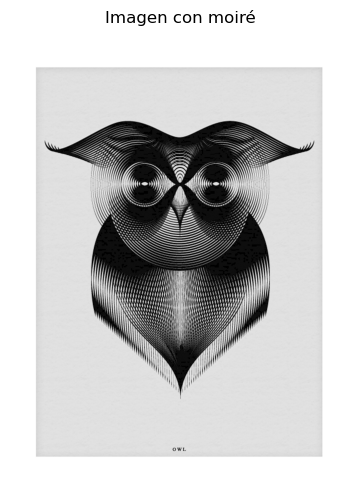

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("imagem.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Imagen con moire")
plt.axis("off")
plt.show()

2-Aplicamos suavizacion

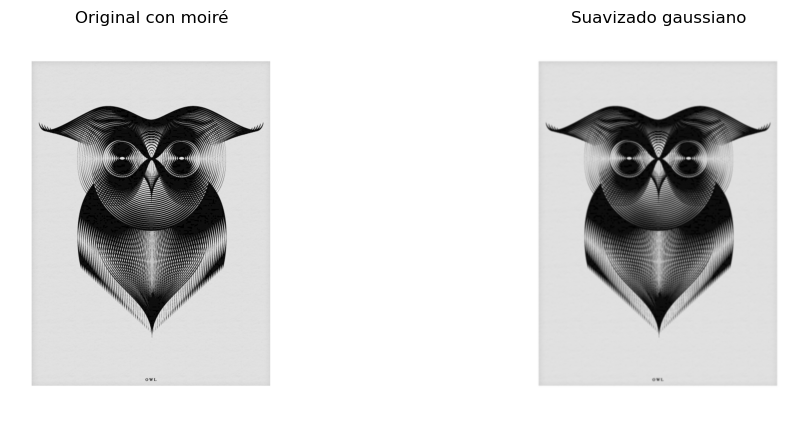

In [ ]:
gauss = cv2.GaussianBlur(img, (5,5), 0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original con moire')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gauss, cmap='gray')
plt.title('Suavizado gaussiano')
plt.axis('off')

plt.show()

3- reduccion de altas frecuencias

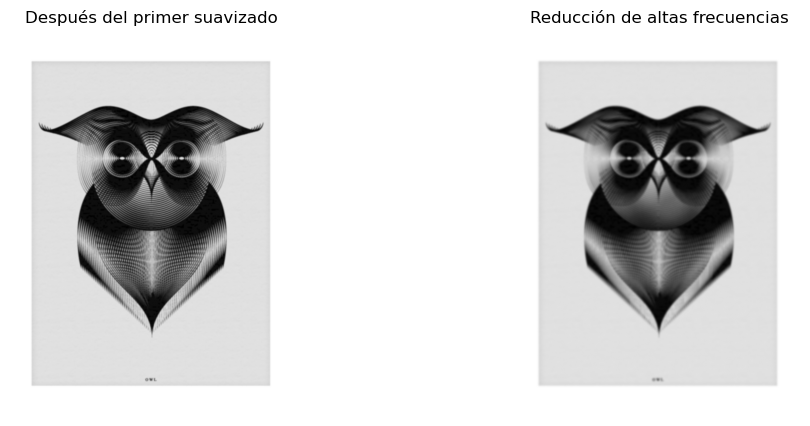

In [ ]:
suave2 = cv2.GaussianBlur(gauss, (9,9), 0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gauss, cmap='gray')
plt.title('Despues del primer suavizado')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(suave2, cmap='gray')
plt.title('Reduccion de altas frecuencias')
plt.axis('off')

plt.show()

4- rezice correcto

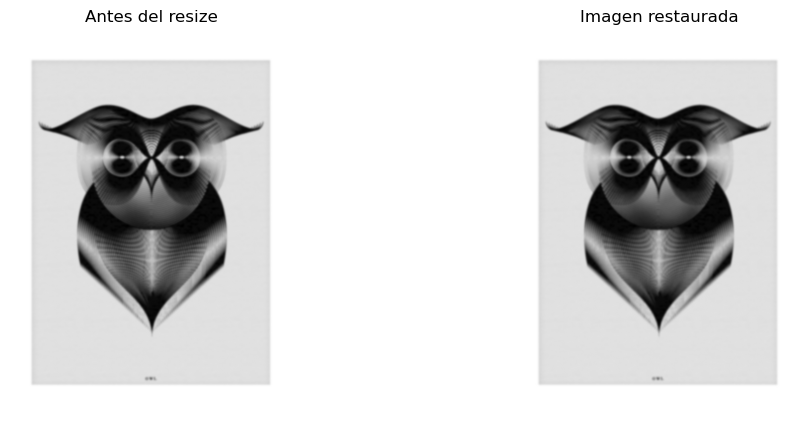

In [13]:
h, w = suave2.shape

# Reducir un poco y volver a escalar correctamente
small = cv2.resize(suave2, (w//2, h//2), interpolation=cv2.INTER_AREA)
restaurada = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(suave2, cmap='gray')
plt.title('Antes del resize')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(restaurada, cmap='gray')
plt.title('Imagen restaurada')
plt.axis('off')

plt.show()

5- Union de todo 

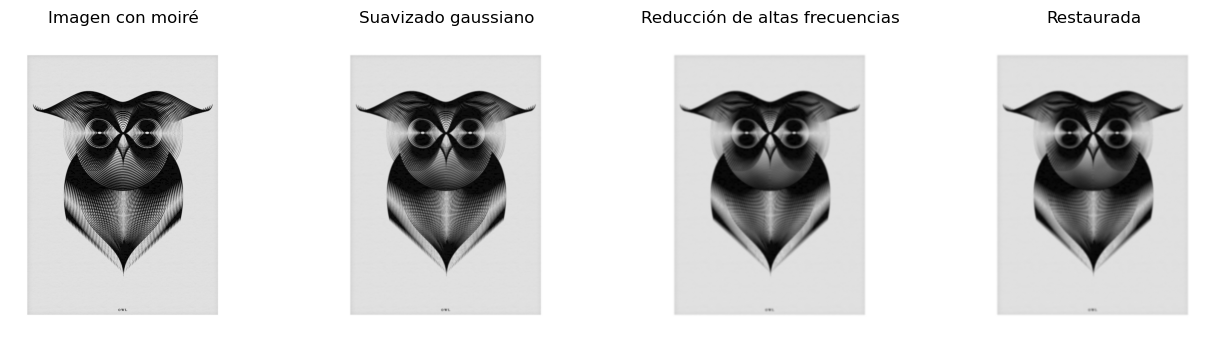

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('imagem.png', 0)

# Suavizado gaussiano
gauss = cv2.GaussianBlur(img, (5,5), 0)

#  Reduccion de altas frecuencias
suave2 = cv2.GaussianBlur(gauss, (9,9), 0)

# Resize correcto
h, w = suave2.shape
small = cv2.resize(suave2, (w//2, h//2), interpolation=cv2.INTER_AREA)
restaurada = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen con moire')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gauss, cmap='gray')
plt.title('Suavizado gaussiano')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(suave2, cmap='gray')
plt.title('Reduccion de altas frecuencias')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(restaurada, cmap='gray')
plt.title('Restaurada')
plt.axis('off')

plt.show()